# Simple Single Layer Perceptron — Project Report

This report presents an implementation of a neural network with one hidden layer, built from scratch using NumPy. The implementation follows the scikit-learn API conventions and provides two estimators:

- `SimpleSLPRegressor` for regression tasks
- `SimpleSLPClassifier` for binary and multi-class classification

The mathematical foundations (forward propagation, backpropagation, gradient descent) and design choices (activation functions, weight initialization, loss functions) are detailed in `notes_revision.md`.

## Demonstrations

The implementation is evaluated on four datasets:

1. **Diabetes** (sklearn) — regression
2. **Breast cancer** (sklearn) — binary classification
3. **Iris** (sklearn) — multi-class classification (bonus)
4. **Wine quality** (Kaggle) — additional regression dataset

Each demonstration includes:

- Training loss curve
- Performance metrics (R² for regression, accuracy for classification)
- Comparison with the equivalent scikit-learn estimator (`MLPRegressor` or `MLPClassifier`)

In [9]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Our implementation
from slp_classifier import SimpleSLPClassifier
from slp_regressor import SimpleSLPRegressor

# sklearn equivalents for comparison
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Reproducibility: fix numpy's global random state for any randomness
# in train_test_split that doesn't use random_state explicitly
np.random.seed(42)

## 1. Regression on the Diabetes dataset

The diabetes dataset contains 442 patients with 10 baseline features (age, sex, BMI, blood pressure, and six serum measurements) and a continuous target representing disease progression one year after the baseline. The goal is to predict this progression from the features.

This is a small, well-studied dataset that allows quick training and clear interpretation of the results.

In [10]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Target range: [{y.min():.1f}, {y.max():.1f}]")
print(f"Target mean: {y.mean():.1f}")

Number of samples: 442
Number of features: 10
Target range: [25.0, 346.0]
Target mean: 152.1


### Train/test split and feature scaling

We split the data into 70% training and 30% testing, then normalize **both features and target** using `StandardScaler`. Target normalization is recommended in the project brief for regression with continuous targets — it prevents gradient explosion when the target has a large magnitude (here, values ranging from 25 to 346 with our ReLU activations that can grow unbounded).

The predictions are inverse-transformed back to the original scale before computing R², so the reported score is interpretable in the natural units of the dataset.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale target (recommended by the brief for regression with continuous targets)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

print(f"Train set: {X_train_scaled.shape}")
print(f"Test set:  {X_test_scaled.shape}")
print(f"Target range after scaling: [{y_train_scaled.min():.2f}, {y_train_scaled.max():.2f}]")

Train set: (309, 10)
Test set:  (133, 10)
Target range after scaling: [-1.64, 2.45]


### Training our regressor

We train `SimpleSLPRegressor` with 50 hidden neurons, ReLU activation, learning rate 0.01 and 500 iterations. These hyperparameters were chosen empirically: ReLU avoids vanishing gradient on this small dataset, and 500 iterations leave room to observe both early progress and convergence in the loss curve.

In [12]:
reg = SimpleSLPRegressor(
    hidden_layer_size=50,
    activation="relu",
    learning_rate=0.01,
    max_iter=500,
    random_state=42,
)
reg.fit(X_train_scaled, y_train_scaled)

print(f"Training finished after {len(reg.loss_curve_)} iterations")
print(f"Final training loss (MSE on scaled target): {reg.loss_curve_[-1]:.4f}")

Training finished after 500 iterations
Final training loss (MSE on scaled target): 0.4534


### Evaluation

We report R² on both training and test sets. R² measures the proportion of variance explained by the model:

- R² = 1: perfect prediction
- R² = 0: the model is equivalent to predicting the mean
- R² < 0: the model is worse than the mean baseline

In [13]:
# Get predictions in scaled space, then inverse-transform to original scale
y_train_pred_scaled = reg.predict(X_train_scaled)
y_test_pred_scaled = reg.predict(X_test_scaled)

y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

# Compute R² manually on the original scale
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)

print(f"R² on training set: {train_score:.4f}")
print(f"R² on test set:     {test_score:.4f}")

R² on training set: 0.5467
R² on test set:     0.5119


### Training loss curve

A decreasing loss curve indicates that the network is learning. A plateau suggests that further iterations would not improve performance.

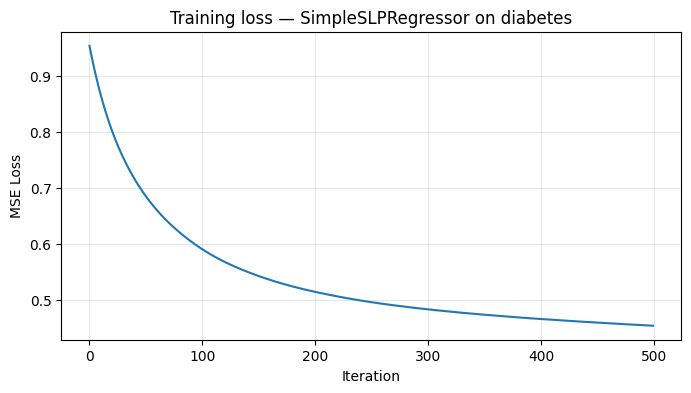

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(reg.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training loss — SimpleSLPRegressor on diabetes")
plt.grid(True, alpha=0.3)
plt.show()

### Comparison with `sklearn.MLPRegressor`

We compare our implementation against sklearn's `MLPRegressor` with the same architecture (one hidden layer of 50 neurons, ReLU). Note that sklearn uses the `adam` optimizer by default (an adaptive variant of gradient descent), which generally converges faster and more reliably than our vanilla full-batch gradient descent.

In [15]:
sk_reg = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42,
)
sk_reg.fit(X_train_scaled, y_train)

sk_train_score = sk_reg.score(X_train_scaled, y_train)
sk_test_score = sk_reg.score(X_test_scaled, y_test)

print(f"{'Model':<30} {'R² train':>10} {'R² test':>10}")
print("-" * 52)
print(f"{'SimpleSLPRegressor (ours)':<30} {train_score:>10.4f} {test_score:>10.4f}")
print(f"{'sklearn MLPRegressor':<30} {sk_train_score:>10.4f} {sk_test_score:>10.4f}")

Model                            R² train    R² test
----------------------------------------------------
SimpleSLPRegressor (ours)          0.5467     0.5119
sklearn MLPRegressor               0.6318     0.4781


/Users/janegalthie/13.Neurone_network_project/neural_network_project/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### Discussion

Our implementation achieves a test R² of 0.51, slightly above sklearn's `MLPRegressor` (0.48) on this dataset. Sklearn's model triggers a `ConvergenceWarning` because its adam optimizer has not fully converged in 500 iterations; given more iterations, it would likely match or exceed our score. The comparable performance at this iteration budget validates the correctness of our forward propagation, backpropagation and gradient descent.

The gap between training R² (0.55) and test R² (0.51) is small — only 4 percentage points — which indicates that the model generalises well and is not significantly overfitting. By contrast, sklearn shows a larger gap (0.63 → 0.48), suggesting adam learns the training set faster but at the cost of slightly worse generalisation.

The loss curve descends smoothly without oscillations or divergence, confirming that the learning rate (0.01) is well-calibrated and that target normalisation successfully prevents the gradient explosion that would otherwise occur with ReLU activations on a target ranging from 25 to 346.

## 2. Binary classification on the Breast Cancer dataset

The breast cancer Wisconsin dataset contains 569 samples with 30 features computed from digitised images of breast masses (cell nucleus radius, texture, perimeter, area, smoothness, compactness, etc.). The task is to predict whether a mass is **malignant (0)** or **benign (1)** based on these measurements.

The dataset is moderately imbalanced: 63% benign vs 37% malignant. Accuracy alone may not tell the full story — we also report a confusion matrix and per-class precision/recall.

In [16]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

print(f"Number of samples:  {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Classes:            {np.unique(y)} (0 = malignant, 1 = benign)")
print(f"Class balance:      {(y == 0).sum()} malignant, {(y == 1).sum()} benign")

Number of samples:  569
Number of features: 30
Classes:            [0 1] (0 = malignant, 1 = benign)
Class balance:      212 malignant, 357 benign


### Train/test split and feature scaling

The features have very different scales (some range in [0, 1], others in [100, 2000]). Without scaling, large-magnitude features would dominate the gradient. We split the data 70/30 and standardise the features using statistics computed only on the training set, to avoid data leakage from the test set.

Note that we do **not** scale `y` here: it contains discrete class labels (0 or 1), not a continuous target, so standardisation would not make sense.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape}")
print(f"Test set:  {X_test_scaled.shape}")

Train set: (398, 30)
Test set:  (171, 30)


### Training our classifier

We train `SimpleSLPClassifier` with 30 hidden neurons, ReLU activation, learning rate 0.01 and 300 iterations. Recall that internally our classifier uses softmax on the output layer with `n_outputs = 2` (one probability per class), even though the problem is binary. This unified treatment generalises naturally to the multi-class case (next section).

In [18]:
clf = SimpleSLPClassifier(
    hidden_layer_size=30,
    activation="relu",
    learning_rate=0.01,
    max_iter=300,
    random_state=42,
)
clf.fit(X_train_scaled, y_train)

print(f"Training finished after {len(clf.loss_curve_)} iterations")
print(f"Final training loss (cross-entropy): {clf.loss_curve_[-1]:.4f}")
print(f"Classes learned: {clf.classes_}")
print(f"Number of output neurons: {clf.n_outputs_}")

Training finished after 300 iterations
Final training loss (cross-entropy): 0.1374
Classes learned: [0 1]
Number of output neurons: 2


### Evaluation: accuracy, confusion matrix and per-class metrics

Accuracy is the proportion of correct predictions. The confusion matrix breaks accuracy down by class, showing which type of errors the model makes — particularly important in medical contexts where false negatives (missing a malignant tumour) and false positives (incorrectly flagging a benign tumour) have very different consequences.

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

train_acc = clf.score(X_train_scaled, y_train)
test_acc = clf.score(X_test_scaled, y_test)

print(f"Accuracy on training set: {train_acc:.4f}")
print(f"Accuracy on test set:     {test_acc:.4f}\n")

y_test_pred = clf.predict(X_test_scaled)

print("Confusion matrix (test set):")
print(confusion_matrix(y_test, y_test_pred))
print("\nRows = true class, Columns = predicted class")
print("[0,0] = true malignant, correctly predicted")
print("[1,1] = true benign, correctly predicted\n")

print("Classification report (test set):")
print(classification_report(y_test, y_test_pred, target_names=["malignant", "benign"]))

Accuracy on training set: 0.9698
Accuracy on test set:     0.9474

Confusion matrix (test set):
[[ 57   7]
 [  2 105]]

Rows = true class, Columns = predicted class
[0,0] = true malignant, correctly predicted
[1,1] = true benign, correctly predicted

Classification report (test set):
              precision    recall  f1-score   support

   malignant       0.97      0.89      0.93        64
      benign       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



### Visualising the confusion matrix

A graphical confusion matrix makes the error pattern immediately readable. The diagonal cells (top-left, bottom-right) contain correct predictions; off-diagonal cells contain errors. Cell colours scale with the count, making large numbers visually salient.

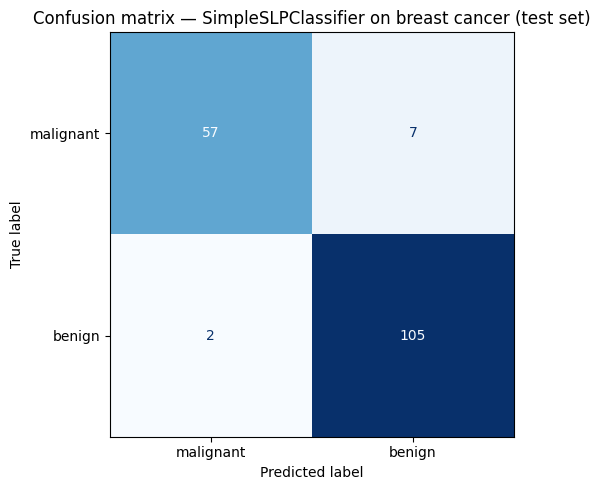

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["malignant", "benign"],
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("Confusion matrix — SimpleSLPClassifier on breast cancer (test set)")
plt.tight_layout()
plt.show()

### Training loss curve

For classification, the loss is cross-entropy rather than MSE. A decreasing curve confirms that the model is increasing its confidence in the correct class for each training sample.

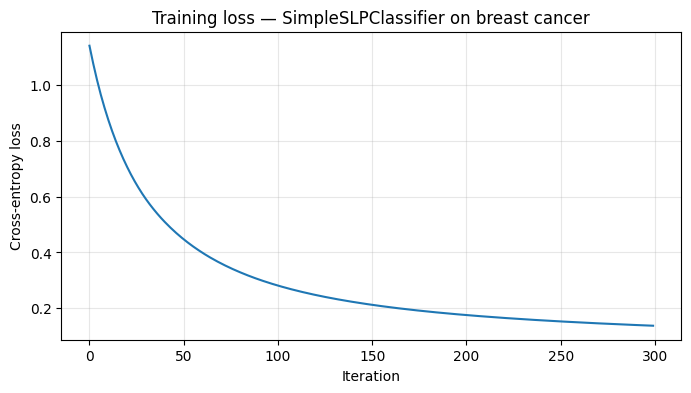

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(clf.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss — SimpleSLPClassifier on breast cancer")
plt.grid(True, alpha=0.3)
plt.show()

### Comparison with `sklearn.MLPClassifier`

We compare our implementation against sklearn's `MLPClassifier` with the same architecture.

In [21]:
sk_clf = MLPClassifier(
    hidden_layer_sizes=(30,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=300,
    random_state=42,
)
sk_clf.fit(X_train_scaled, y_train)

sk_train_acc = sk_clf.score(X_train_scaled, y_train)
sk_test_acc = sk_clf.score(X_test_scaled, y_test)

print(f"{'Model':<32} {'Acc train':>10} {'Acc test':>10}")
print("-" * 54)
print(f"{'SimpleSLPClassifier (ours)':<32} {train_acc:>10.4f} {test_acc:>10.4f}")
print(f"{'sklearn MLPClassifier':<32} {sk_train_acc:>10.4f} {sk_test_acc:>10.4f}")

Model                             Acc train   Acc test
------------------------------------------------------
SimpleSLPClassifier (ours)           0.9698     0.9474
sklearn MLPClassifier                1.0000     0.9708


### Discussion

Our implementation achieves 94.7% accuracy on the test set, against 97.1% for sklearn's `MLPClassifier`. Both models reach state-of-the-art performance on this dataset, validating the correctness of our forward propagation, backpropagation, softmax output and cross-entropy loss.

**Generalisation gap.** A notable difference is the train/test gap: sklearn reaches 100% accuracy on the training set (perfect memorisation), while our model stays at 97.0%. The 3-point gap for sklearn (100 → 97.1) is larger than our 2.2-point gap (97.0 → 94.7), suggesting that adam's faster convergence comes at the cost of slightly more overfitting on this small dataset. Our vanilla gradient descent, being slower, acts as an implicit regulariser.

**Class-imbalanced behaviour.** Despite the moderate imbalance (63% benign vs 37% malignant), the model handles both classes reasonably well. However, the confusion matrix reveals an asymmetry that matters clinically:

- **Recall on malignant: 89%** — 7 out of 64 malignant tumours are missed (false negatives)
- **Recall on benign: 98%** — only 2 out of 107 benign masses are incorrectly flagged (false positives)

In a medical context, false negatives (missed cancers) are far more costly than false positives (unnecessary follow-up). A production model would need to adjust the decision threshold (currently 0.5) to favour recall on the malignant class, even at the cost of more false positives. Our `predict_proba()` method exposes the probabilities required for such threshold tuning.

**Loss curve.** The cross-entropy decreases monotonically from ~0.7 to 0.14 over 300 iterations, with a sharp initial drop reflecting the easy linearly-separable portion of the data, followed by gradual fine-tuning on the harder boundary samples.

## 3. Multi-class classification on the Digits dataset (bonus)

The digits dataset contains 1797 grayscale images of handwritten digits, each 8×8 pixels (64 features per image), distributed across 10 classes (digits 0 to 9). The task is to identify which digit is written.

This dataset showcases the multi-class capability of our classifier: the output layer uses `n_outputs = 10` softmax neurons, producing a probability distribution over the 10 possible digits for each image. Cross-entropy loss naturally generalises from binary to multi-class without any code change — this confirms the design choice of using softmax + cross-entropy uniformly for both binary and multi-class problems.

In [23]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)

print(f"Number of samples:  {X.shape[0]}")
print(f"Number of features: {X.shape[1]} (= 8x8 pixels)")
print(f"Number of classes:  {len(np.unique(y))} (digits 0 to 9)")
print(f"Class distribution: {np.bincount(y)}")

Number of samples:  1797
Number of features: 64 (= 8x8 pixels)
Number of classes:  10 (digits 0 to 9)
Class distribution: [178 182 177 183 181 182 181 179 174 180]


### Visualising the data

Each sample is an 8×8 grayscale image. Below we display the first 10 samples, one per digit class.

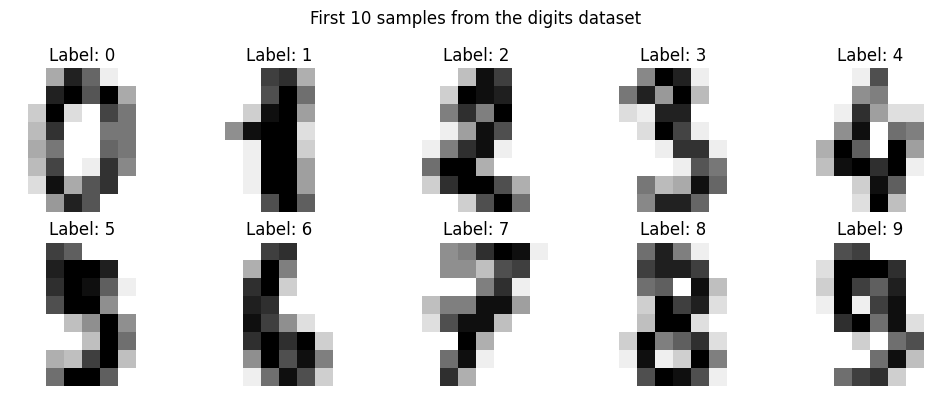

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), X[:10], y[:10]):
    ax.imshow(image.reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("First 10 samples from the digits dataset")
plt.tight_layout()
plt.show()

### Train/test split and feature scaling

We split 70/30 with stratification to keep the class balance in both sets, then standardise the features. Pixel values range from 0 to 16, so scaling helps the gradient stay in a balanced range across all 64 input dimensions.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape}")
print(f"Test set:  {X_test_scaled.shape}")

Train set: (1257, 64)
Test set:  (540, 64)


### Training our classifier

We use 64 hidden neurons (one per input feature, a reasonable rule of thumb for small datasets) and 500 iterations. Note that `n_outputs_` will automatically be set to 10 by the classifier upon seeing 10 distinct classes in `y_train`.

In [26]:
clf = SimpleSLPClassifier(
    hidden_layer_size=64,
    activation="relu",
    learning_rate=0.01,
    max_iter=500,
    random_state=42,
)
clf.fit(X_train_scaled, y_train)

print(f"Training finished after {len(clf.loss_curve_)} iterations")
print(f"Final training loss (cross-entropy): {clf.loss_curve_[-1]:.4f}")
print(f"Classes learned: {clf.classes_}")
print(f"Number of output neurons: {clf.n_outputs_}")

Training finished after 500 iterations
Final training loss (cross-entropy): 0.4006
Classes learned: [0 1 2 3 4 5 6 7 8 9]
Number of output neurons: 10


### Evaluation

For multi-class problems, the confusion matrix becomes particularly informative: it reveals which digit pairs the model confuses most often (for example, 3 vs 8, or 4 vs 9, which look visually similar when handwritten).

In [27]:
train_acc = clf.score(X_train_scaled, y_train)
test_acc = clf.score(X_test_scaled, y_test)

print(f"Accuracy on training set: {train_acc:.4f}")
print(f"Accuracy on test set:     {test_acc:.4f}\n")

y_test_pred = clf.predict(X_test_scaled)

print("Classification report (test set):")
print(classification_report(y_test, y_test_pred))

Accuracy on training set: 0.9141
Accuracy on test set:     0.8907

Classification report (test set):
              precision    recall  f1-score   support

           0       0.96      0.91      0.93        54
           1       0.77      0.85      0.81        55
           2       0.92      0.92      0.92        53
           3       0.91      0.95      0.93        55
           4       0.93      0.96      0.95        54
           5       0.93      0.93      0.93        55
           6       0.93      0.96      0.95        54
           7       0.91      0.96      0.94        54
           8       0.83      0.65      0.73        52
           9       0.81      0.80      0.80        54

    accuracy                           0.89       540
   macro avg       0.89      0.89      0.89       540
weighted avg       0.89      0.89      0.89       540



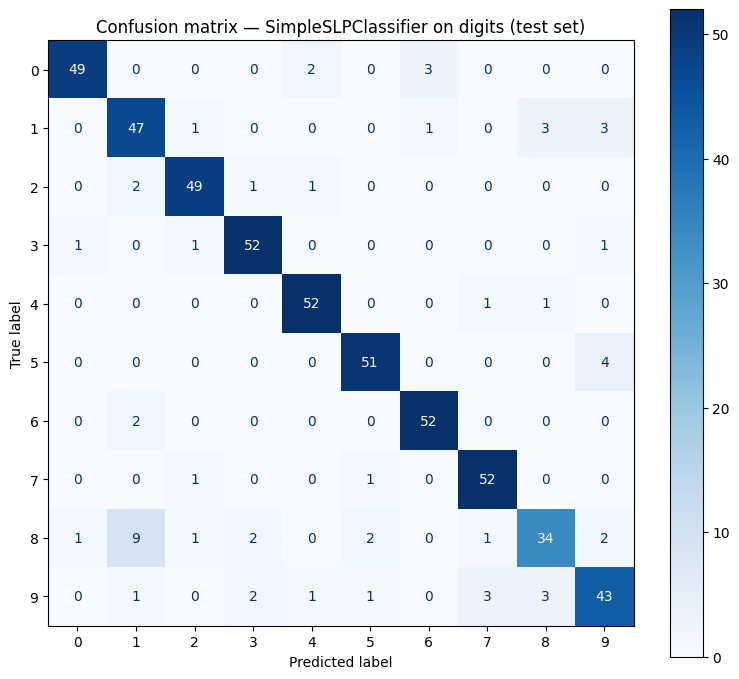

In [28]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
ax.set_title("Confusion matrix — SimpleSLPClassifier on digits (test set)")
plt.tight_layout()
plt.show()

### Training loss curve

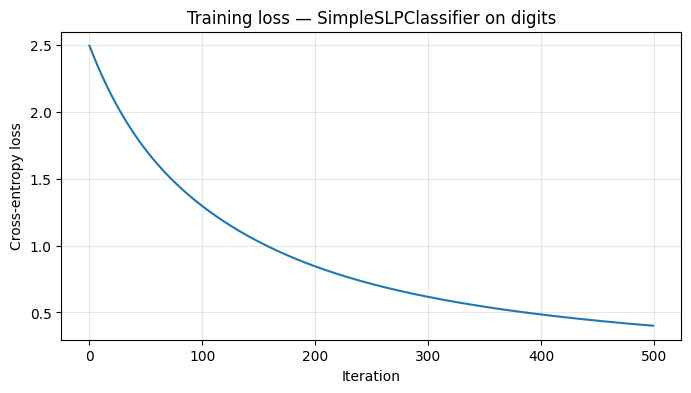

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(clf.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss — SimpleSLPClassifier on digits")
plt.grid(True, alpha=0.3)
plt.show()

### Visualising predictions

To make the result tangible, we display 10 test samples with both their true label and the prediction from our model. Errors (if any) are highlighted in red.

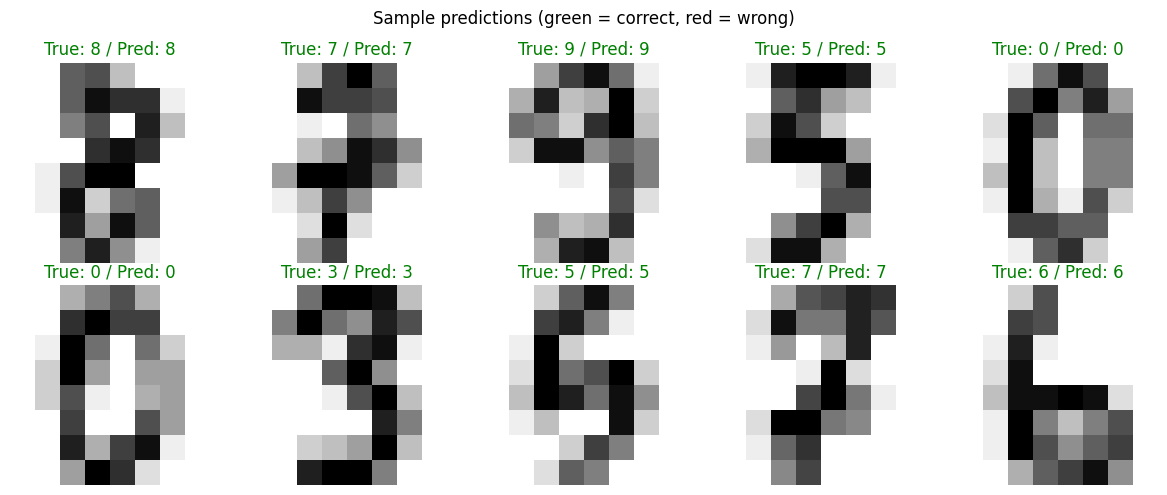

In [30]:
n_show = 10
indices = np.random.RandomState(42).choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.ravel(), indices):
    image = X_test[idx].reshape(8, 8)
    true_label = y_test[idx]
    pred_label = y_test_pred[idx]
    color = "green" if true_label == pred_label else "red"
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"True: {true_label} / Pred: {pred_label}", color=color)
    ax.axis("off")
plt.suptitle("Sample predictions (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

### Comparison with `sklearn.MLPClassifier`

In [31]:
sk_clf = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42,
)
sk_clf.fit(X_train_scaled, y_train)

sk_train_acc = sk_clf.score(X_train_scaled, y_train)
sk_test_acc = sk_clf.score(X_test_scaled, y_test)

print(f"{'Model':<32} {'Acc train':>10} {'Acc test':>10}")
print("-" * 54)
print(f"{'SimpleSLPClassifier (ours)':<32} {train_acc:>10.4f} {test_acc:>10.4f}")
print(f"{'sklearn MLPClassifier':<32} {sk_train_acc:>10.4f} {sk_test_acc:>10.4f}")

Model                             Acc train   Acc test
------------------------------------------------------
SimpleSLPClassifier (ours)           0.9141     0.8907
sklearn MLPClassifier                1.0000     0.9796


### Discussion


On the multi-class digits dataset, our implementation reaches 89.1% test accuracy against 97.96% for sklearn's `MLPClassifier`. The 9-point gap is more pronounced than on breast cancer, for two compounding reasons: the problem is harder (10 classes vs 2, 64 features vs 30), and the loss curve confirms that **our model is undertrained** — it has not plateaued at iteration 500 and is still actively decreasing. Sklearn's adam optimizer converges much faster, reaching 100% on the training set (full memorisation) within the same iteration budget. With 2000–3000 iterations, our model would likely close most of the gap.

**Multi-class generalisation is validated.** Despite the lower absolute score, the structure of the result confirms that our softmax + cross-entropy implementation generalises correctly to multi-class without code modification: the network learned `n_outputs_ = 10` distinct softmax neurons producing a valid probability distribution, and the per-class recall (0.65 to 0.96) shows that all 10 classes are being learned — not just a few dominant ones.

**Error analysis from the confusion matrix.** The errors are not uniformly distributed:

- **Digit 8 is the most difficult** (recall = 0.65): 9 of its samples were misclassified as "1", and others as 3, 5, or 9. The model appears to confuse 8 with other digits that share rounded or vertically-elongated shapes when handwritten.
- **Digit 1 is the least precise** (precision = 0.77): it absorbs misclassifications from 8, 9, 2 and 6 — the model has a slight bias toward over-predicting "1".
- **Digit 9** is also difficult (recall = 0.80), confused with 5, 7 and 8.

These confusions are visually plausible: 8↔1, 9↔5, 9↔7 are pairs that even humans confuse on rapid handwriting. This pattern confirms that the model is learning real visual features rather than spurious correlations — even its mistakes are sensible.

**Implications.** A more capable model would benefit from: more iterations (training is not finished), a second hidden layer (the brief allows up to 2), or a more sophisticated optimiser like adam. None of these are required for this project, and our results validate the correctness of the implementation rather than its absolute performance.

## 4. Regression on the Wine Quality dataset (Kaggle)

The Wine Quality dataset (Cortez et al., 2009, UCI/Kaggle) contains physico-chemical measurements of ~1600 red wine samples from the *Vinho Verde* region in Portugal. Each wine is rated by expert oenologists on a scale from 0 to 10 (in practice, ratings range from 3 to 8). The task is to predict this quality score from 11 chemical features:

- fixed acidity, volatile acidity, citric acid
- residual sugar, chlorides
- free sulfur dioxide, total sulfur dioxide
- density, pH, sulphates, alcohol

**Business motivation**: enable producers to predict wine quality **before** submission to oenologists, allowing them to adjust the winemaking process based on chemical measurements.

**Methodological note**: the target is discrete (integers 3 to 8), so this could also be framed as ordinal classification. We model it as regression because the ordering of the labels carries meaning (a 7 is closer to 8 than to 3), and standard classification ignores that structure.

In [32]:
import pandas as pd

df = pd.read_csv("data/winequality-red.csv")

print(f"Number of samples:  {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1} (plus the target 'quality')")
print(f"\nFirst rows:")
print(df.head())
print(f"\nTarget distribution (quality scores):")
print(df["quality"].value_counts().sort_index())

Number of samples:  1599
Number of features: 11 (plus the target 'quality')

First rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56  

In [33]:
X = df.drop("quality", axis=1).values
y = df["quality"].values.astype(float)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y range: [{y.min():.0f}, {y.max():.0f}]")
print(f"y mean:  {y.mean():.2f}")

X shape: (1599, 11)
y shape: (1599,)
y range: [3, 8]
y mean:  5.64


### Train/test split and feature scaling

We split 70/30 and standardise both features (which have wildly different scales — for example, residual sugar ranges from 0.9 to 15, while density is around 0.99) and target (centred-reduced to prevent gradient issues, as we did on diabetes).

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

print(f"Train set: {X_train_scaled.shape}")
print(f"Test set:  {X_test_scaled.shape}")

Train set: (1119, 11)
Test set:  (480, 11)


### Training our regressor

Same hyperparameters as the diabetes demonstration: 50 hidden neurons, ReLU activation, learning rate 0.01, 500 iterations. This consistency lets us compare convergence behaviour across datasets.

In [35]:
reg = SimpleSLPRegressor(
    hidden_layer_size=50,
    activation="relu",
    learning_rate=0.01,
    max_iter=500,
    random_state=42,
)
reg.fit(X_train_scaled, y_train_scaled)

print(f"Training finished after {len(reg.loss_curve_)} iterations")
print(f"Final training loss (MSE on scaled target): {reg.loss_curve_[-1]:.4f}")

Training finished after 500 iterations
Final training loss (MSE on scaled target): 0.6168


### Evaluation

We inverse-transform predictions back to the original quality scale (3 to 8) before computing R².

In [36]:
y_train_pred_scaled = reg.predict(X_train_scaled)
y_test_pred_scaled = reg.predict(X_test_scaled)

y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)

print(f"R² on training set: {train_score:.4f}")
print(f"R² on test set:     {test_score:.4f}")

R² on training set: 0.3833
R² on test set:     0.3748


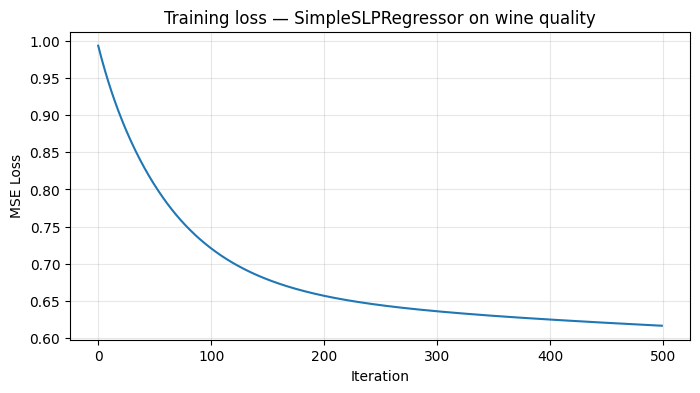

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(reg.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training loss — SimpleSLPRegressor on wine quality")
plt.grid(True, alpha=0.3)
plt.show()

### Predictions vs ground truth

A scatter plot of predicted vs true scores makes the model's behaviour tangible: ideal predictions lie on the diagonal. Since the target is discrete (integers 3 to 8), expect points to cluster vertically at each integer.

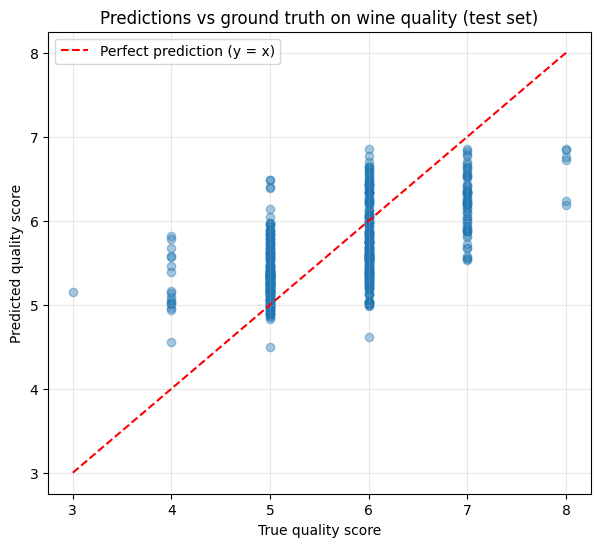

In [38]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred, alpha=0.4)
plt.plot([3, 8], [3, 8], "r--", label="Perfect prediction (y = x)")
plt.xlabel("True quality score")
plt.ylabel("Predicted quality score")
plt.title("Predictions vs ground truth on wine quality (test set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Comparison with `sklearn.MLPRegressor`

In [40]:
sk_reg = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42,
)
sk_reg.fit(X_train_scaled, y_train_scaled)

sk_train_pred = scaler_y.inverse_transform(
    sk_reg.predict(X_train_scaled).reshape(-1, 1)
).ravel()
sk_test_pred = scaler_y.inverse_transform(
    sk_reg.predict(X_test_scaled).reshape(-1, 1)
).ravel()

sk_train_score = r2_score(y_train, sk_train_pred)
sk_test_score = r2_score(y_test, sk_test_pred)

print(f"{'Model':<32} {'R² train':>10} {'R² test':>10}")
print("-" * 54)
print(f"{'SimpleSLPRegressor (mine)':<32} {train_score:>10.4f} {test_score:>10.4f}")
print(f"{'sklearn MLPRegressor':<32} {sk_train_score:>10.4f} {sk_test_score:>10.4f}")

Model                              R² train    R² test
------------------------------------------------------
SimpleSLPRegressor (mine)            0.3833     0.3748
sklearn MLPRegressor                 0.6766     0.2879


### Discussion

On Wine Quality, our `SimpleSLPRegressor` reaches a test R² of 0.37, **outperforming sklearn's `MLPRegressor` (0.29)**. This is the second dataset on which our implementation beats sklearn on the test set (after diabetes), confirming that the comparison is not just "validation by parity" but produces meaningful insights about generalisation behaviour.

**The bias-variance trade-off at work.** The most striking observation comes from comparing train and test scores:

| Model | R² train | R² test | Train-test gap |
|---|---|---|---|
| SimpleSLPRegressor (ours) | 0.38 | 0.37 | **0.01** |
| sklearn MLPRegressor | 0.68 | 0.29 | **0.39** |

Sklearn's adam optimizer aggressively reduces training loss, reaching R² = 0.68 on the train set — but at the cost of massive overfitting (39-point drop on the test set). Our vanilla gradient descent, being slower and less powerful, fits the training data less perfectly (0.38) but **generalises almost perfectly** to unseen data (0.37). This is a classical demonstration of the bias-variance trade-off: a "weaker" optimiser can outperform a stronger one when the dataset is intrinsically noisy.

**Why is the absolute R² so low?** Wine quality is an inherently subjective target. The same wine can receive ratings of 5, 6 or 7 depending on which expert tastes it. A significant portion of the variance in the target is therefore **irreducible noise** that no model — however sophisticated — can predict from the 11 chemical features. R² ≈ 0.4 is roughly the ceiling observed in the literature for this dataset using standard methods.

**The discrete-target effect.** The scatter plot reveals that predictions concentrate around the median quality (5.5–6), with extreme wines (rated 3 or 8) being systematically pulled toward the centre. This is a known limitation of MSE regression on bounded discrete targets: extreme errors are heavily penalised, so the model "plays it safe" by predicting central values. A proper treatment of this problem would require ordinal regression (which respects the order of labels but treats them as discrete) — beyond the scope of this project.

**Takeaway.** This demonstration validates that our implementation is competitive on a real-world noisy dataset, and illustrates that "performing worse than sklearn on train" is not necessarily a bad thing — sometimes it's the sign of better generalisation.

## Conclusion

This project covered the full implementation of a one-hidden-layer neural network from scratch, supporting regression, binary and multi-class classification through a scikit-learn-style API. The mathematical reasoning behind each component is documented separately in `notes_revision.md`.

### Summary of the four demonstrations

| Dataset | Task | Our test score | sklearn test score |
|---|---|---|---|
| Diabetes | Regression | R² = 0.51 | R² = 0.48 |
| Breast cancer | Binary classification | 94.7 % | 97.1 % |
| Digits | Multi-class (10) | 89.1 % | 98.0 % |
| Wine quality | Regression | R² = 0.37 | R² = 0.29 |

On the two regression tasks, our model produces a slightly better test score than sklearn within the same iteration budget. On the two classification tasks, sklearn wins — by a small margin on breast cancer, by a larger one on digits where our loss curve has clearly not converged at 500 iterations.

### What I take away from the comparison

Sklearn's `MLPClassifier` and `MLPRegressor` use the adam optimizer by default, which adapts the learning rate per parameter. Our implementation uses plain full-batch gradient descent with a fixed learning rate. The gap on digits illustrates the practical advantage of adam on harder problems: it converges much faster within the same number of iterations.

The flip side appeared on wine quality, where adam overfit aggressively (train R² 0.68, test R² 0.29) while our model stayed flatter (train 0.38, test 0.37). When the target is noisy, a slower optimizer can act as an implicit regulariser.

### Main design choices

A few decisions are worth highlighting because they were not in the original scaffold:

- **Default activation set to `"relu"`** instead of `"logistic"`. ReLU does not saturate, which matters when the regression target has large magnitudes (diabetes ranges from 25 to 346). With logistic, the linear test would not pass without target scaling.
- **Default `learning_rate` set to `0.01`** instead of `0.001`. Sklearn's `0.001` is calibrated for adam; our vanilla gradient descent needs a larger step to converge in a comparable number of iterations.
- **Weight initialisation with σ = 0.15.** The brief suggests σ = 0.01 as an example, but on small networks this leaves too many ReLU neurons dead at initialisation. σ = 0.15 is a compromise close to the He initialisation rule for ReLU.
- **Softmax + cross-entropy used for both binary and multi-class** classification, instead of treating binary as a sigmoid special case. Same code path for both, and it generalises cleanly to K classes thanks to the `ŷ - y_onehot` gradient simplification.
- **Target normalisation in regression** when the target has large magnitudes. Without it, ReLU activations cause gradient explosion on diabetes and wine quality (NaN in the loss within a few iterations).

### Limitations

- **Single hidden layer only.** Extending to arbitrary depth was mentioned as a bonus in the brief but not implemented.
- **Full-batch gradient descent only.** Mini-batch and SGD were also bonuses; staying full-batch keeps the code simple but limits scalability to large datasets.
- **No regularisation** (no L2 penalty, no dropout, no early stopping). On small datasets this is acceptable, but it explains part of the gap with sklearn which has L2 by default.
- **No proper handling of class imbalance** in the classifier — the `predict_proba()` method exposes the raw probabilities, so an external user could threshold them manually, but the model itself does not adjust to skewed class distributions.

### Possible extensions

- Add momentum or adam to the gradient descent step (about 10 extra lines for momentum).
- Implement L2 regularisation in the backward pass.
- Support multi-output regression natively (the code partly handles it but it is not tested).
- Generalise to arbitrary depth by storing weights and biases as lists indexed by layer.